In [1]:
import pandas as pd

df = pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [2]:
# Drop unnecessary columns
df = df.drop(['url', 'phone'], axis=1, errors='ignore')

# Remove null values
df = df.dropna()

# Clean 'rate' column
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Drop nulls again after conversion
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23259 entries, 0 to 51715
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      23259 non-null  object 
 1   name                         23259 non-null  object 
 2   online_order                 23259 non-null  object 
 3   book_table                   23259 non-null  object 
 4   rate                         23259 non-null  float64
 5   votes                        23259 non-null  int64  
 6   location                     23259 non-null  object 
 7   rest_type                    23259 non-null  object 
 8   dish_liked                   23259 non-null  object 
 9   cuisines                     23259 non-null  object 
 10  approx_cost(for two people)  23259 non-null  object 
 11  reviews_list                 23259 non-null  object 
 12  menu_item                    23259 non-null  object 
 13  listed_in(type)      

In [2]:
# Drop unnecessary columns
df = df.drop(['url', 'phone'], axis=1, errors='ignore')

# Remove null values
df = df.dropna()

# Clean 'rate' column
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Drop nulls again after conversion
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23259 entries, 0 to 51715
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      23259 non-null  object 
 1   name                         23259 non-null  object 
 2   online_order                 23259 non-null  object 
 3   book_table                   23259 non-null  object 
 4   rate                         23259 non-null  float64
 5   votes                        23259 non-null  int64  
 6   location                     23259 non-null  object 
 7   rest_type                    23259 non-null  object 
 8   dish_liked                   23259 non-null  object 
 9   cuisines                     23259 non-null  object 
 10  approx_cost(for two people)  23259 non-null  object 
 11  reviews_list                 23259 non-null  object 
 12  menu_item                    23259 non-null  object 
 13  listed_in(type)      

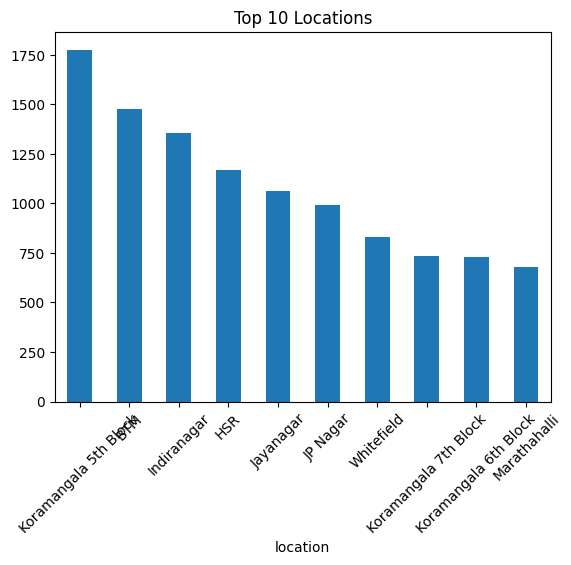

In [3]:
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

top_locations.plot(kind='bar')
plt.title("Top 10 Locations")
plt.xticks(rotation=45)
plt.show()

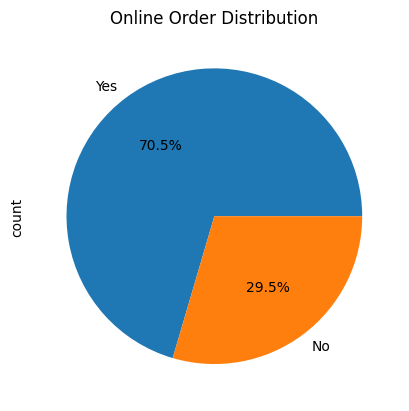

In [4]:
import matplotlib.pyplot as plt

df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Online Order Distribution")
plt.show()

In [6]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


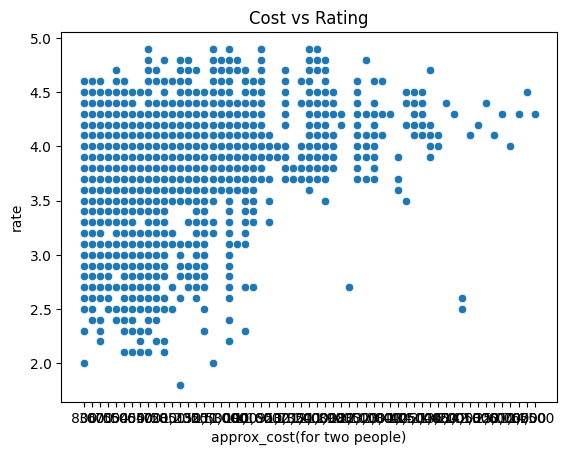

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Cost vs Rating")
plt.show()

## Cost vs Rating Insights

- Most restaurants fall in mid-price range with ratings between 3.5–4.5
- Very expensive restaurants do not always have higher ratings
- Budget restaurants show mixed ratings (both low and high)
- No strong correlation between cost and rating → price doesn’t guarantee quality